In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# VSCode Jupyter sets __vsc_ipynb_file__ to the absolute path of this notebook.
# Change to the notebook directory so all relative file loads work correctly.
try:
    os.chdir(Path(__vsc_ipynb_file__).parent)
except NameError:
    pass  # Not VSCode — working directory already correct

# Problem Set 3 - Inversion Theory
## Student Name: (Enter your name here)

In this Jupyter Notebook, you will explore linear and non-linear inversion.  We will start with a linear least squares inversion using linear data, then linearize data to similarly solve the problem.  Then we will determine the Jacobian/Frechet matrix for a non-linear inversion using Newton's method.

### Problem 1 -- Vp vs Density
In this problem, you will use the average densities and seismic velocities determined in the previous practical for various rock types to develop a model that converts density into seismic velocity.

In [25]:
df = pd.read_csv('property_summary_by_rocktype.csv')
df

,rock_type,RHO,SD_RHO,Vp,SD_Vp,Vs,SD_Vs,TC,SD_TC,HP,SD_HP
0,granite,2660,32.9,6.17,0.0670,3.72,0.0178,2.78,0.1380,3.420,5.040
1,granodiorite,2720,35.3,6.40,0.0877,3.76,0.0303,2.61,0.1280,1.740,2.930
2,diorite,2790,38.4,6.65,0.1040,3.84,0.0420,2.47,0.1260,1.180,2.220
3,gabbroic diorite,2900,53.3,6.95,0.1580,3.94,0.0809,2.45,0.2030,0.659,1.500
4,subalkalic gabbro,2950,46.4,7.14,0.1490,3.99,0.0695,2.41,0.1680,0.340,0.727
5,syenite,2660,47.3,6.35,0.1040,3.77,0.0426,2.26,0.1280,5.230,37.700
6,monzonite,2760,35.6,6.62,0.1080,3.84,0.0552,2.32,0.1400,2.400,9.720
7,monzodiorite,2840,36.0,6.82,0.1170,3.91,0.0691,2.25,0.1410,1.400,2.100
8,monzogabbro,2900,35.0,6.96,0.1260,3.96,0.0634,2.18,0.1640,1.010,2.610
9,alkalic gabbro,2950,43.1,7.06,0.1250,3.99,0.0657,2.23,0.1740,0.486,0.652


## Linear least squares: Vp = m0 + m1 * RHO

We solve the system $\mathbf{G}\,\mathbf{m} = \mathbf{d}$ where

$$\mathbf{G} = \begin{bmatrix} 1 & \rho_1 \\ \vdots & \vdots \\ 1 & \rho_N \end{bmatrix}, \quad
\mathbf{m} = \begin{bmatrix} m_0 \\ m_1 \end{bmatrix}, \quad
\mathbf{d} = \begin{bmatrix} V_{p,1} \\ \vdots \\ V_{p,N} \end{bmatrix}$$

**Unweighted** (ordinary least squares):
$$\hat{\mathbf{m}} = (\mathbf{G}^T \mathbf{G})^{-1} \mathbf{G}^T \mathbf{d}$$

Post-fit data variance estimate: $\hat{\sigma}^2 = \|\mathbf{d} - \mathbf{G}\hat{\mathbf{m}}\|^2 \,/\, (N - 2)$

Model covariance: $\mathbf{C}_m = \hat{\sigma}^2 (\mathbf{G}^T \mathbf{G})^{-1}$

**Weighted** (errors-in-observations):
$$\hat{\mathbf{m}}_w = (\mathbf{G}^T \mathbf{W} \mathbf{G})^{-1} \mathbf{G}^T \mathbf{W} \mathbf{d}, \quad
\mathbf{W} = \mathrm{diag}(1/\sigma_{V_p}^2)$$

Model covariance: $\mathbf{C}_{m,w} = (\mathbf{G}^T \mathbf{W} \mathbf{G})^{-1}$

Prediction uncertainty at any $\rho$: $\sigma_{\hat{d}}(\rho) = \sqrt{\mathbf{g}(\rho)^T \mathbf{C}_m \,\mathbf{g}(\rho)}$
where $\mathbf{g}(\rho) = [1,\, \rho]^T$.

In [26]:
rho  = df['RHO'].values.astype(float)
vp   = df['Vp'].values.astype(float)
svp  = df['SD_Vp'].values.astype(float)

N = len(rho)

# Design matrix
G = np.column_stack([np.ones(N), rho])

# --- Unweighted least squares ---
GtG     = G.T @ G
GtG_inv = np.linalg.inv(GtG)
m_uw    = GtG_inv @ G.T @ vp

resid_uw   = vp - G @ m_uw
s2_uw      = (resid_uw @ resid_uw) / (N - 2)   # post-fit variance estimate
Cm_uw      = s2_uw * GtG_inv

print('Unweighted:  m0 = {:.4f} km/s,  m1 = {:.6f} km/s per kg/m³'.format(*m_uw))
print('             post-fit sigma_d = {:.4f} km/s'.format(np.sqrt(s2_uw)))

# --- Weighted least squares (W = diag(1/sigma_Vp^2)) ---
w       = 1.0 / svp**2
GtWG    = G.T @ (w[:, None] * G)
GtWG_inv = np.linalg.inv(GtWG)
m_w     = GtWG_inv @ (G.T @ (w * vp))
Cm_w    = GtWG_inv

print()
print('Weighted:    m0 = {:.4f} km/s,  m1 = {:.6f} km/s per kg/m³'.format(*m_w))

Unweighted:  m0 = -1.2878 km/s,  m1 = 0.002844 km/s per kg/m³
             post-fit sigma_d = 0.0525 km/s

Weighted:    m0 = -1.4275 km/s,  m1 = 0.002887 km/s per kg/m³


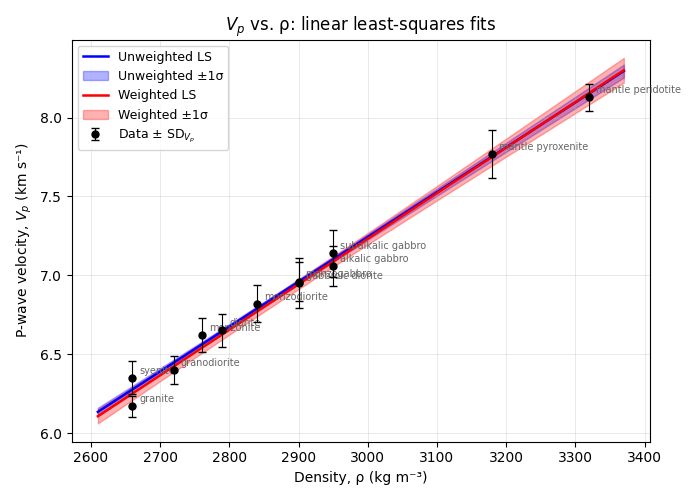

In [27]:
# Prediction grid
rho_grid = np.linspace(rho.min() - 50, rho.max() + 50, 300)
G_grid   = np.column_stack([np.ones_like(rho_grid), rho_grid])

# Predicted Vp
vp_pred_uw = G_grid @ m_uw
vp_pred_w  = G_grid @ m_w

# Prediction uncertainty: sigma(rho) = sqrt( g^T Cm g ) for each grid point
sig_uw = np.sqrt(np.einsum('ij,jk,ik->i', G_grid, Cm_uw, G_grid))
sig_w  = np.sqrt(np.einsum('ij,jk,ik->i', G_grid, Cm_w,  G_grid))

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5))

# Data
ax.errorbar(rho, vp, yerr=svp, fmt='ko', ms=5, capsize=3, lw=0.8,
            label='Data ± SD$_{V_p}$', zorder=5)

# Rock type labels
for _, row in df.iterrows():
    ax.annotate(row['rock_type'], (row['RHO'], row['Vp']),
                textcoords='offset points', xytext=(5, 3), fontsize=7, color='0.4')

# Unweighted fit + uncertainty band
ax.plot(rho_grid, vp_pred_uw, 'b-', lw=1.8, label='Unweighted LS')
ax.fill_between(rho_grid,
                vp_pred_uw - sig_uw,
                vp_pred_uw + sig_uw,
                color='b', alpha=0.3, label='Unweighted ±1σ')

# Weighted fit + uncertainty band
ax.plot(rho_grid, vp_pred_w, 'r-', lw=1.8, label='Weighted LS')
ax.fill_between(rho_grid,
                vp_pred_w - sig_w,
                vp_pred_w + sig_w,
                color='r', alpha=0.3, label='Weighted ±1σ')

ax.set_xlabel('Density, ρ (kg m⁻³)')
ax.set_ylabel('P-wave velocity, $V_p$ (km s⁻¹)')
ax.set_title('$V_p$ vs. ρ: linear least-squares fits')
ax.legend(fontsize=9)
ax.grid(True, lw=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

In [28]:
# Misfit metrics
resid_w   = vp - G @ m_w
rms_uw    = np.sqrt(np.mean(resid_uw**2))
rms_w     = np.sqrt(np.mean(resid_w**2))
chi2_uw   = np.sum((resid_uw / svp)**2)          # chi-squared using observed errors
chi2_w    = np.sum((resid_w  / svp)**2)
rchi2_uw  = chi2_uw / (N - 2)                    # reduced chi-squared
rchi2_w   = chi2_w  / (N - 2)

# Summary table
print('Model comparison')
print('-' * 55)
print(f'{"":20s}  {"Unweighted":>14s}  {"Weighted":>14s}')
print(f'{"intercept m0 (km/s)":20s}  {m_uw[0]:>14.4f}  {m_w[0]:>14.4f}')
print(f'{"slope m1 (km/s per":20s}')
print(f'{"  kg/m³) × 10⁻³":20s}  {m_uw[1]*1e3:>14.4f}  {m_w[1]*1e3:>14.4f}')
print(f'{"σ(m0) (km/s)":20s}  {np.sqrt(Cm_uw[0,0]):>14.4f}  {np.sqrt(Cm_w[0,0]):>14.4f}')
print(f'{"σ(m1) × 10⁻³":20s}  {np.sqrt(Cm_uw[1,1])*1e3:>14.4f}  {np.sqrt(Cm_w[1,1])*1e3:>14.4f}')
print(f'{"RMS misfit (km/s)":20s}  {rms_uw:>14.4f}  {rms_w:>14.4f}')
print(f'{"χ²":20s}  {chi2_uw:>14.4f}  {chi2_w:>14.4f}')
print(f'{"χ²_red":20s}  {rchi2_uw:>14.4f}  {rchi2_w:>14.4f}')

Model comparison
-------------------------------------------------------
                          Unweighted        Weighted
intercept m0 (km/s)          -1.2878         -1.4275
slope m1 (km/s per  
  kg/m³) × 10⁻³               2.8436          2.8865
σ(m0) (km/s)                  0.2287          0.4016
σ(m1) × 10⁻³                  0.0791          0.1404
RMS misfit (km/s)             0.0479          0.0511
χ²                            3.9391          3.5247
χ²_red                        0.3939          0.3525


#### Questions:
1. How well does the unweighted model fit the data?

(your answer here)

2. Does using a weighted model improve the model fit?

(your answer here)

### Problem 2 -- Thermal Conductivity

In [29]:
import zipfile, re
from pathlib import Path

def load_xlsx_sheet(filename, sheet_name):
    """Read a worksheet from .xlsx files that use a non-standard OOXML namespace,
    which causes openpyxl / pandas.read_excel to report zero sheets."""
    with zipfile.ZipFile(filename) as z:
        # Shared strings table
        raw = z.read('xl/sharedStrings.xml').decode('utf-8')
        shared = re.findall(r'<t[^>]*>(.*?)</t>', raw, re.DOTALL)
        def unescape(s):
            for a, b in (('&amp;','&'),('&lt;','<'),('&gt;','>'),('&quot;','"'),('&apos;',"'")):
                s = s.replace(a, b)
            return s
        shared = [unescape(s) for s in shared]

        # workbook.xml → rId for the named sheet
        wb  = z.read('xl/workbook.xml').decode('utf-8')
        rel = z.read('xl/_rels/workbook.xml.rels').decode('utf-8')
        rels = dict(re.findall(r'Id="([^"]+)"[^>]+Target="([^"]+)"', rel))
        pat = r'name="{n}"[^>]*r:id="([^"]+)"|r:id="([^"]+)"[^>]*name="{n}"'.format(
                  n=re.escape(sheet_name))
        m = re.search(pat, wb)
        if not m:
            raise KeyError(f"Sheet '{sheet_name}' not found. "
                           f"Available: {re.findall(r'name=\"([^\"]+)\"', wb)}")
        rid = next(g for g in m.groups() if g)
        target = rels[rid]
        if not target.startswith('xl/'):
            target = 'xl/' + target

        # Parse worksheet cells
        ws = z.read(target).decode('utf-8')
        rows_xml = re.findall(r'<row[^>]*>(.*?)</row>', ws, re.DOTALL)

        def col_idx(letters):          # 'A'→0, 'B'→1, 'AA'→26 …
            n = 0
            for c in letters:
                n = n * 26 + ord(c) - 64
            return n - 1

        def parse_row(row_xml):
            cells = re.findall(r'<c ([^>]*)>(.*?)</c>', row_xml, re.DOTALL)
            out = {}
            for attrs, body in cells:
                ref = re.search(r'r="([A-Z]+)\d+"', attrs)
                typ = re.search(r't="([^"]+)"',     attrs)
                val = re.search(r'<v>(.*?)</v>',    body, re.DOTALL)
                if not ref or not val:
                    continue
                v = val.group(1).strip()
                if typ and typ.group(1) == 's':
                    v = shared[int(v)]
                else:
                    try: v = float(v)
                    except ValueError: pass
                out[col_idx(ref.group(1))] = v
            return out

        header = parse_row(rows_xml[0])
        ncols  = max(header) + 1
        cols   = [header.get(i, f'col_{i}') for i in range(ncols)]
        data   = [[parse_row(r).get(i, float('nan')) for i in range(ncols)]
                  for r in rows_xml[1:]]

    return pd.DataFrame(data, columns=cols)

# --- Load 'A. Database' sheet ---
tc = load_xlsx_sheet('thermal_conductivity_data.xlsx', 'A. Database')
print(f"Loaded {len(tc)} rows × {len(tc.columns)} columns")
tc.head()

Loaded 1225 rows × 51 columns


,Sample Name,Rock Group,Rock Origin,Sample Type,Rock Type,SiO2,TiO2,Al2O3,Fe2O3,FeO,...,Magnetite,Ilmenite,Hematite,Apatite,Total Used,Density dry,Density saturated,Porosity,Thermal Conductivity,St. Dev.
0,CC-002,igneous,plutonic,outcrop,subalkalic gabbro,48.11,0.14,23.12,0.80,2.33,...,1.999605,0.266435,0.0,0.023216,97.977176,2877.134705,2.1655,NaN,NaN,0.073308
1,CC-021,igneous,plutonic,outcrop,subalkalic gabbro,50.58,0.34,16.47,0.90,5.33,...,3.902393,0.642694,0.0,0.069181,96.028422,2893.612365,2.2354,NaN,NaN,0.037060
2,CC-023,igneous,plutonic,outcrop,subalkalic gabbro,49.59,0.25,17.62,1.87,4.02,...,3.679927,0.473518,0.0,0.046214,96.273852,2924.102494,2.4196,NaN,NaN,0.051814
3,CC-026,igneous,plutonic,outcrop,subalkalic gabbro,50.12,0.26,16.57,1.02,4.18,...,3.297825,0.492995,0.0,0.046265,96.655902,2901.198350,2.1858,NaN,NaN,0.044025
4,CC-035,igneous,plutonic,outcrop,subalkalic gabbro,50.82,0.40,16.29,2.06,4.68,...,4.136621,0.749672,0.0,0.045728,95.817646,2888.202003,2.1464,NaN,NaN,0.070529


In [30]:
# Load mineral thermal conductivity data from 'B. Mineral Conductivity' sheet
tc_min = load_xlsx_sheet('thermal_conductivity_data.xlsx', 'B. Mineral Conductivity')

print(f"Loaded {len(tc_min)} measurements across {tc_min['Mineral'].nunique()} minerals")
print("Minerals:", sorted(tc_min['Mineral'].unique()))
tc_min

Loaded 201 measurements across 12 minerals
Minerals: ['amphibole', 'biotite', 'clinopyroxene', 'garnet', 'hornblende', 'ilmenite', 'kspar', 'mica', 'olivine', 'orthopyroxene', 'plagioclase', 'quartz']


,Mineral,Thermal Conductivity,Composition,Reference
0,biotite,2.33662,0.00,Horai (1971)
1,biotite,1.69708,0.00,Horai (1971)
2,clinopyroxene,5.56358,0.00,Horai (1971)
3,clinopyroxene,5.17066,0.00,Horai (1971)
4,clinopyroxene,4.05042,0.00,Horai (1971)
...,...,...,...,...
196,quartz,9.80000,NaN,Hoefer & Schilling (2002)
197,plagioclase,2.02000,0.12,"Linvill, Vandersande, Pohl (1984)"
198,plagioclase,1.72000,0.58,"Linvill, Vandersande, Pohl (1984)"
199,plagioclase,1.69000,0.65,"Linvill, Vandersande, Pohl (1984)"


## Geometric mean mixing model

The bulk thermal conductivity of a rock is estimated as a **geometric mean** of its constituent mineral conductivities, weighted by their volumetric (normative) fractions:

$$k_\text{rock} = \prod_{i=1}^{M} k_i^{w_i}, \qquad \sum_i w_i = 1$$

Taking logarithms linearises the problem:

$$\underbrace{\log k_\text{rock}}_{d} = \sum_{i=1}^{M} w_i \underbrace{\log k_i}_{m_i}
\quad \Longrightarrow \quad \mathbf{G}\,\mathbf{m} = \mathbf{d}$$

where each row of **G** contains the CIPW normative weight fractions for one rock sample and **m** = [log k₁, …, log k_M]ᵀ are the unknown log-conductivities.

**Ordinary least squares** in log-space:

$$\hat{\mathbf{m}} = (\mathbf{G}^T \mathbf{G})^{-1} \mathbf{G}^T \mathbf{d}$$

Post-fit variance: $\hat{\sigma}^2 = \|\mathbf{d} - \mathbf{G}\hat{\mathbf{m}}\|^2 / (N - M)$

Model covariance: $\mathbf{C}_m = \hat{\sigma}^2 (\mathbf{G}^T \mathbf{G})^{-1}$

Mineral conductivities and their uncertainties are recovered via the delta method:

$$\hat{k}_i = e^{\hat{m}_i}, \qquad \sigma_{k_i} \approx \hat{k}_i \sqrt{[C_m]_{ii}}$$

In [31]:
# Geometric mean mixing model: log(k_rock) = sum_i [ w_i * log(k_i) ]
# CIPW norm columns grouped into petrographic mineral names
mineral_groups = {
    'quartz':        ['Quartz'],
    'kspar':         ['Orthoclase'],
    'plagioclase':   ['Albite', 'Anorthite'],
    'clinopyroxene': ['Diopside'],
    'orthopyroxene': ['Hypersthene Mg', 'Hypersthene Fe'],
    'olivine':       ['Olivine'],
    'ilmenite':      ['Ilmenite'],
}
inv_minerals = list(mineral_groups.keys())
all_cipw = [c for cols in mineral_groups.values() for c in cols]

# Coerce all relevant columns to numeric
tc_num = tc.copy()
for col in ['Thermal Conductivity', 'Total Used'] + all_cipw:
    tc_num[col] = pd.to_numeric(tc_num[col], errors='coerce')

# Build weight-fraction columns (CIPW wt% / Total Used)
for mineral, cols in mineral_groups.items():
    tc_num[mineral] = tc_num[cols].sum(axis=1) / tc_num['Total Used'].clip(lower=1)

# Keep rows with valid TC, reasonable Total Used, and no NaN fractions
mask = (tc_num['Thermal Conductivity'] > 0) & (tc_num['Total Used'] > 50)
tc_inv = tc_num[mask].dropna(subset=['Thermal Conductivity'] + inv_minerals)

G_rock = tc_inv[inv_minerals].values
d_rock = np.log(tc_inv['Thermal Conductivity'].values)
N_rock, M_rock = G_rock.shape

# Least-squares inversion
m_rock, _, _, _ = np.linalg.lstsq(G_rock, d_rock, rcond=None)
resid_rock = d_rock - G_rock @ m_rock
s2_rock    = (resid_rock @ resid_rock) / max(N_rock - M_rock, 1)
Cm_rock    = s2_rock * np.linalg.pinv(G_rock.T @ G_rock)
k_inv_est  = np.exp(m_rock)
sig_k_inv  = k_inv_est * np.sqrt(np.diag(Cm_rock))   # error propagation through exp

print(f"N = {N_rock} samples,  post-fit σ = {np.sqrt(s2_rock):.4f} (log-space)")
print(f"\n{'Mineral':>15s}  {'k (W/m/K)':>10s}  {'±1σ':>8s}")
for mn, ki, si in zip(inv_minerals, k_inv_est, sig_k_inv):
    print(f"{mn:>15s}  {ki:>10.3f}  {si:>8.3f}")

N = 179 samples,  post-fit σ = 0.1060 (log-space)

        Mineral   k (W/m/K)       ±1σ
         quartz       5.094     0.236
          kspar       2.021     0.126
    plagioclase       2.073     0.095
  clinopyroxene       2.821     0.436
  orthopyroxene       3.786     0.717
        olivine       2.697     0.505
       ilmenite       0.066     0.054


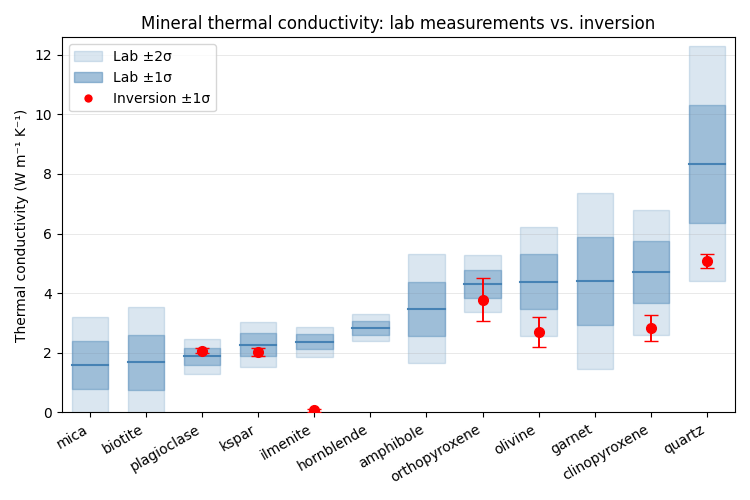

In [33]:
import matplotlib.patches as mpatches

# tc_min 'Mineral' column already uses the same names as inv_minerals
cond_col = next(
    (c for c in tc_min.columns if 'conduct' in str(c).lower()),
    tc_min.columns[1]
)

tc_min_c = tc_min.copy()
tc_min_c[cond_col] = pd.to_numeric(tc_min_c[cond_col], errors='coerce')
tc_min_c = tc_min_c.dropna(subset=['Mineral', cond_col])

# Compute stats for every mineral present in tc_min
lab_stats = {}
for mn in tc_min_c['Mineral'].unique():
    vals = tc_min_c.loc[tc_min_c['Mineral'] == mn, cond_col].values
    lab_stats[mn] = (vals.mean(), vals.std(ddof=1) if len(vals) > 1 else 0.0, len(vals))

# Sort by mean conductivity
ordered = sorted(lab_stats, key=lambda x: lab_stats[x][0])
x_pos   = np.arange(len(ordered))

# --- Plot ---
fig, ax = plt.subplots(figsize=(7.5, 5))

y_all = []

for i, mn in enumerate(ordered):
    mu, sigma, _ = lab_stats[mn]
    y_all += [mu - 2*sigma, mu + 2*sigma]
    w = 0.65
    ax.add_patch(mpatches.Rectangle(
        (i - w/2, mu - 2*sigma), w, 4*sigma,
        color='steelblue', alpha=0.2, zorder=1))
    ax.add_patch(mpatches.Rectangle(
        (i - w/2, mu - sigma), w, 2*sigma,
        color='steelblue', alpha=0.4, zorder=2))
    ax.plot([i - w/2, i + w/2], [mu, mu], color='steelblue', lw=1.5, zorder=3)

# Overlay inversion estimates only for minerals in inv_minerals
first = True
for i, mn in enumerate(ordered):
    if mn in inv_minerals:
        idx = inv_minerals.index(mn)
        y_all += [k_inv_est[idx] - sig_k_inv[idx], k_inv_est[idx] + sig_k_inv[idx]]
        ax.errorbar(i, k_inv_est[idx], yerr=sig_k_inv[idx],
                    fmt='ro', ms=7, capsize=5, lw=1.4, zorder=5,
                    label='Inversion ±1σ' if first else '_nolegend_')
        first = False

# Explicit limits (add_patch doesn't trigger autoscale)
pad = 0.3
ax.set_xlim(-0.5, len(ordered) - 0.5)
ax.set_ylim(max(0, min(y_all) - pad), max(y_all) + pad)

ax.set_xticks(x_pos)
ax.set_xticklabels(ordered, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Thermal conductivity (W m⁻¹ K⁻¹)')
ax.set_title('Mineral thermal conductivity: lab measurements vs. inversion')
ax.grid(True, axis='y', lw=0.4, alpha=0.5)

handles = [
    mpatches.Patch(color='steelblue', alpha=0.2, label='Lab ±2σ'),
    mpatches.Patch(color='steelblue', alpha=0.5, label='Lab ±1σ'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='r',
               markersize=7, label='Inversion ±1σ'),
]
ax.legend(handles=handles, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

### Problem 3 -- Mineral conductivity

In [ ]:
# --- Load lab dataset ---
from pathlib import Path
path = Path('tc_plag.csv')
if not path.exists():
    raise FileNotFoundError('Missing tc_plag.csv. Place the file in this folder and rerun.')

dat = pd.read_csv(path)
if dat.shape[1] < 3:
    dat = pd.read_csv(path)
    if not {'An','T','k'}.issubset(set(dat.columns)):
        raise ValueError('Expect 3 columns: x(An), T(K), k.')
    X = dat[['An','T']].to_numpy()
    k = dat['k'].to_numpy()
else:
    arr = dat.to_numpy()
    X = arr[:, :2]
    k = arr[:, 2]

# Starting model and run
m0 = np.array([2.0, 0.1, -0.02, 0.8])
m, sm, hist = gauss_newton(X, k, m0, lam=0.0)
print('Gauss--Newton solution:')
for i,(mi,si) in enumerate(zip(m, sm)):
    print(f" m[{i}] = {mi:.4f} ± {1.96*si:.4f} (≈95% CI)")
print('Iter  RMS   alpha')
for it, rms, a in hist:
    print(f"{it:>3d}  {rms:7.4f}  {a:4.2f}")

# Visualization: curves at a few An values
colors = ['k','r','g','b']
for xi, col in zip([0.0, 0.2, 0.55, 1.0], colors):
    TT = np.linspace(np.min(X[:,1]), np.max(X[:,1]), 200)
    kk = forward(m, np.c_[xi*np.ones_like(TT), TT])
    plt.plot(TT, kk, color=col, lw=2, label=f'An={xi}')
plt.scatter(X[:,1], k, c=X[:,0], cmap='cool', s=16, alpha=0.6, label='data')
plt.xlabel('Temperature (K)'); plt.ylabel('k (W/m/K)'); plt.legend(); plt.title('Fitted conductivity'); plt.show()

NameError: name 'pd' is not defined